In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import importlib

In [56]:
import eoc_eod_functions
importlib.reload(eoc_eod_functions)
from eoc_eod_functions import *

In [4]:
## Load MetaData
cap_tests = pd.read_excel('/home/tamoghna/Matlab/Mehran_stuff/Metadata_and_Code/00_Data/00_Metadata/Capacity_Tests.xlsx')
systems_md = pd.read_excel('/home/tamoghna/Matlab/Mehran_stuff/Metadata_and_Code/00_Data/00_Metadata/Metadata_Systems.xlsx')

In [19]:
systems_md.head()

,ID,Capacity_nominal_in_Ah,Voltage_nominal_in_V,Energy_nominal_in_kWh,Energy_usable_datasheet_in_kWh,Cell_number_in_series,Cell_number_in_parallel,Cell_number,Inverter_nominal_power,Manufacturer,Chemistry,Chemistry_detail,Date_storage_system_installation,Date_measurement_system_installation
0,1,15.0,146.666667,2.2,2.0,40,1,40,2.0,A,LMO,LMO/NMC,1426201200,1436486400
1,2,15.0,146.666667,2.2,2.0,40,1,40,2.0,A,LMO,LMO/NMC,1418943600,1450706306
2,3,15.0,146.666667,2.2,2.0,40,1,40,2.0,A,LMO,LMO/NMC,1431640800,1464048000
3,4,15.0,146.666667,2.2,2.0,40,1,40,2.0,A,LMO,LMO/NMC,1453244400,1466546400
4,5,15.0,146.666667,2.2,2.0,40,1,40,2.0,A,LMO,LMO/NMC,1416610800,1471384800


In [46]:
op_datapath_6 = '/home/tamoghna/Matlab/Mehran_stuff/Metadata_and_Code/00_Data/01_Operational_Data/Data_ID_06/06'
op_datapath_7 = '/home/tamoghna/Matlab/Mehran_stuff/Metadata_and_Code/00_Data/01_Operational_Data/Data_ID_07/07'

y=2020
m=7
sample_data = pd.read_csv(f'{op_datapath_6}/{y}_0{m}_System_ID_06.csv')

In [47]:
sample_data['Time'] = pd.to_datetime(sample_data['Time'])
timegap = (sample_data['Time'] - sample_data['Time'].iloc[0])
seconds = timegap.apply(lambda x: pd.Timedelta(x).total_seconds())
sample_data['Seconds'] = seconds


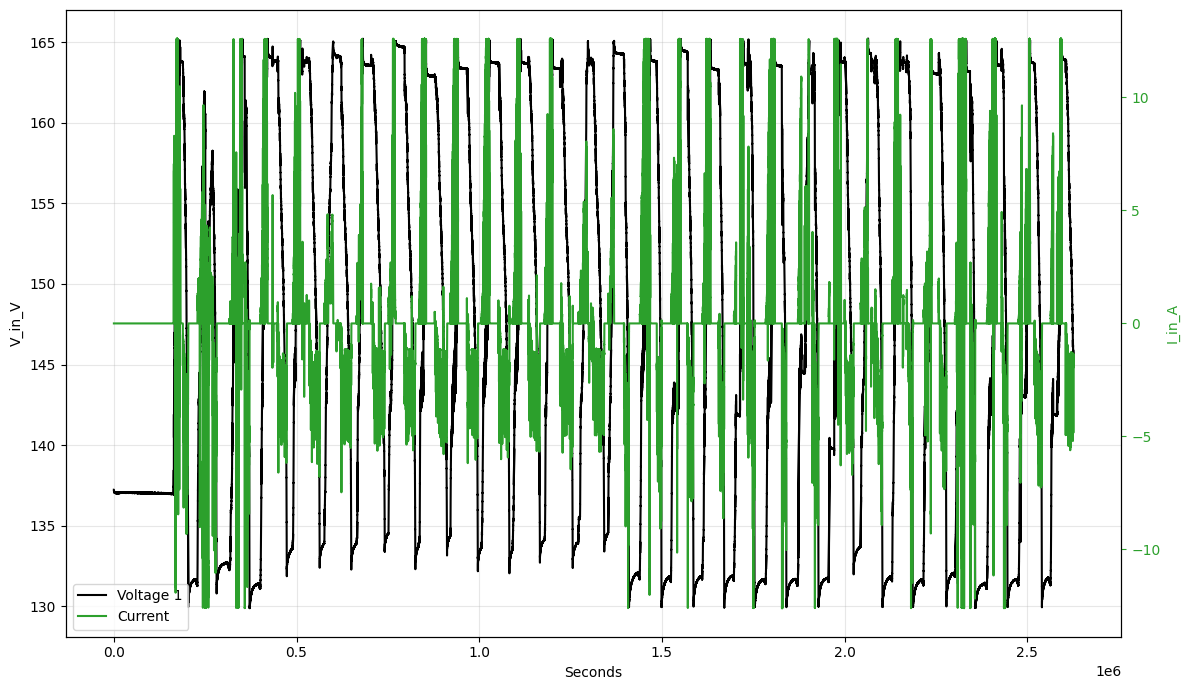

In [53]:
column_map = {1: 'V_in_V', 2: 'I_in_A'}
plot_multi_axis(sample_data, column_map, ('Voltage 1', 'Current'), x='Seconds')
plt.show()

In [65]:
cell_v, capacity = cell_level_scaling(systems_md, 6)

charge_relaxations, discharge_relaxations = detect_relaxation_after_throughput(
    seconds=sample_data['Seconds'],
    current=sample_data['I_in_A'],
    voltage=sample_data['V_in_V'],
    capacity_ah=capacity,
    min_duration=900
)

In [66]:
discharge_relaxations, charge_relaxations

([], [])

In [59]:
relax = sample_data[(sample_data['Seconds'] >= charge_relaxations[0][0]) & (sample_data['Seconds'] <= charge_relaxations[0][1])]

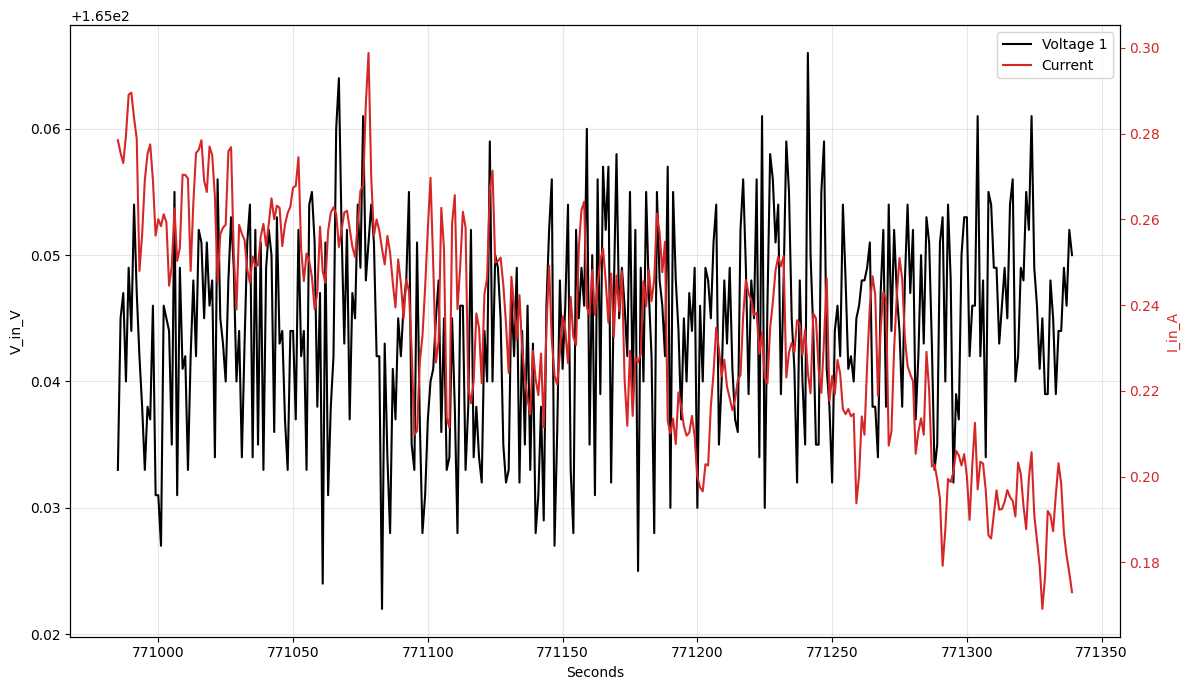

In [61]:
column_map = {1: 'V_in_V', 2: 'I_in_A'}
plot_multi_axis(relax, column_map, ('Voltage 1', 'Current'), x='Seconds')
plt.show()